# Assignment: Logistic Regression on Imbalanced E-Commerce Purchase Data

## Objective

An e-commerce company wants to predict whether a visitor session will lead to a purchase.

The target column is `Revenue`:

- `True`: visitor purchased
- `False`: visitor did not purchase

This is a **binary classification problem** with class imbalance. Your goal is to train logistic regression models and compare different methods for handling imbalance.

## Business Context

If the model predicts that a visitor is likely to purchase, the company may show a discount popup, a special offer, or live sales assistance.

But there is a tradeoff:

- High **recall** means we catch more actual buyers, but may show offers to many non-buyers.
- High **precision** means fewer wasted offers, but we may miss some actual buyers.

Your final answer should recommend a model based on this business tradeoff.

## Dataset

We will use the Online Shoppers Purchasing Intention dataset.

Dataset URL:

```text
https://raw.githubusercontent.com/sharmaroshan/Online-Shoppers-Purchasing-Intention/master/online_shoppers_intention.csv
```

The dataset has website session-level features such as page visits, page durations, bounce rates, exit rates, visitor type, month, weekend flag, and whether the session generated revenue.

## Tasks

Complete the notebook by filling the `TODO` sections.

You need to compare four approaches:

1. Baseline Logistic Regression with default threshold `0.5`
2. Threshold tuning using predicted probabilities
3. Logistic Regression with `class_weight="balanced"`
4. SMOTE + Logistic Regression

For each approach, report:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

Finally, answer the business questions at the end.

## 1. Setup

Run the install cell only if any package is missing.

In [74]:
# Run this only if required.
# %pip install numpy pandas matplotlib seaborn scikit-learn imbalanced-learn

In [75]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load the Dataset

Load the dataset from the given URL.

In [76]:
DATA_URL = "https://raw.githubusercontent.com/sharmaroshan/Online-Shoppers-Purchasing-Intention/master/online_shoppers_intention.csv"

# TODO: Load the dataset into a DataFrame named df.
# Hint: use pd.read_csv(DATA_URL)
shoppers_df = pd.read_csv(DATA_URL)
# raise NotImplementedError("Load the dataset")

In [77]:
# TODO: Display the first 5 rows and check the shape.
print(shoppers_df.shape)
shoppers_df.head()

# raise NotImplementedError("Inspect the dataset")

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3. Check Class Imbalance

The target column is `Revenue`.

Check how many sessions led to purchase and how many did not.

In [78]:
# TODO: Show count and percentage distribution of df["Revenue"].
# Hint: use value_counts() and value_counts(normalize=True)
Revenue_counts = shoppers_df["Revenue"].value_counts()
Revenue_percentages = shoppers_df["Revenue"].value_counts(normalize=True)

print("Count distribution of Revenue:")
print(Revenue_counts)
print("\nPercentage distribution of Revenue:")
print(Revenue_percentages)

# raise NotImplementedError("Check class imbalance")

Count distribution of Revenue:
Revenue
False    10422
True      1908
Name: count, dtype: int64

Percentage distribution of Revenue:
Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64


### Question 1

Is this dataset balanced or imbalanced? Why?

Write your answer here:

-Given dataset is highly imblance w.r.t target variable Revenue having binary classes with uneven distribution. 85% & 15%

## 4. Select Features

To keep the assignment lightweight, we will use a limited set of useful features.

Numerical features:

```python
[
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]
```

Categorical features:

```python
["Month", "VisitorType", "Weekend"]
```

Target:

```python
"Revenue"
```

In [79]:
numeric_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

categorical_features = ["Month", "VisitorType", "Weekend"]
target = "Revenue"

# TODO: Create X and y.
# X should contain numeric_features + categorical_features.
# y should be 1 for purchase and 0 for no purchase.
# Hint: df[target].astype(int)
X = shoppers_df[numeric_features + categorical_features]
y = shoppers_df[target].astype(int)


# raise NotImplementedError("Create X and y")

## 5. Train-Test Split

Use a stratified split so the train and test sets preserve the same class ratio.

In [80]:
# TODO: Split the data into train and test sets.
# Use test_size=0.2, random_state=RANDOM_STATE, and stratify=y.
X_train,X_test,Y_train,Y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("X Train set shape:", X_train.shape)
print("X Test set shape:", X_test.shape)
print("Y Train set shape:", Y_train.shape)
print("Y Test set shape:", Y_test.shape)

# raise NotImplementedError("Create stratified train-test split")

X Train set shape: (9864, 13)
X Test set shape: (2466, 13)
Y Train set shape: (9864,)
Y Test set shape: (2466,)


In [81]:
# TODO: Check class distribution in y_train and y_test.
y_train_distribution = Y_train.value_counts(normalize=True)
y_test_distribution = Y_test.value_counts(normalize=True)
print("Y Train class distribution:")
print(y_train_distribution)
print("Y Test class distribution:")
print(y_test_distribution)
# raise NotImplementedError("Check train-test class distribution")

Y Train class distribution:
Revenue
0    0.845296
1    0.154704
Name: proportion, dtype: float64
Y Test class distribution:
Revenue
0    0.845093
1    0.154907
Name: proportion, dtype: float64


### Question 2

Why did we use `stratify=y` during train-test split?

Write your answer here:

- **Maintain equal proportion:** It preserve the exact percentage distribution of each class from the original dataset.
- **Blanced Split:** It ensures both the training and testing sets receive an equal proportion of target categories.
- **Protects Rare Classess:** It stops minority classess from being completely excluded from either dataset by chance.
- **Accurate Evaluation:** It yealds realistic performance materices because the test set accurately mirrors the real-world data distribution.

## 6. Preprocessing

We will:

- Scale numeric features using `StandardScaler`
- One-hot encode categorical features using `OneHotEncoder`

The preprocessing should be fit only on the training data.

In [82]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category","bool"]).columns.tolist()

numeric_features, categorical_features
# X_train.head()

(['Administrative',
  'Administrative_Duration',
  'Informational',
  'Informational_Duration',
  'ProductRelated',
  'ProductRelated_Duration',
  'BounceRates',
  'ExitRates',
  'PageValues',
  'SpecialDay'],
 ['Month', 'VisitorType', 'Weekend'])

In [83]:
# TODO: Create preprocessing steps for numeric and categorical features.
# Hint:
# - Use StandardScaler() for numeric features.
# - Use OneHotEncoder(handle_unknown="ignore") for categorical features.
# - Combine both using ColumnTransformer.
# - Name the numeric transformer "num" and categorical transformer "cat".
#
# For OneHotEncoder, newer scikit-learn versions use sparse_output=False,
# while older versions use sparse=False. You can use the try-except pattern below.
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", drop="first", sparse=False)

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", one_hot_encoder)
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 7. Helper Function for Evaluation

Use this helper function to evaluate every model consistently.

In [84]:
def evaluate_predictions(y_true, y_pred, model_name):
    """Return a dictionary of key classification metrics."""
    # TODO: Return a dictionary with the following keys:
    # "model", "accuracy", "precision", "recall", "f1"
    #
    # Hint:
    # - "model" should store model_name.
    # - Use accuracy_score(y_true, y_pred).
    # - Use precision_score(y_true, y_pred, zero_division=0).
    # - Use recall_score(y_true, y_pred, zero_division=0).
    # - Use f1_score(y_true, y_pred, zero_division=0).
    # raise NotImplementedError("Complete evaluate_predictions function")
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

def show_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["No Purchase", "Purchase"],
        yticklabels=["No Purchase", "Purchase"]
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## 8. Baseline Logistic Regression

Train a normal logistic regression model.

Use default threshold `0.5`.

In [85]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# TODO: Fit baseline_model on X_train and y_train.
# TODO: Predict on X_test and store predictions in y_pred_baseline.
baseline_model.fit(X_train, Y_train)
baseline_predictions = baseline_model.predict(X_test)
baseline_model


# raise NotImplementedError("Train and predict baseline logistic regression")

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Administrative','Administrative_Duration','Informational',...,'Month', 'VisitorType','Weekend']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

Baseline Model Metrics:
model: Baseline Logistic Regression
accuracy: 0.8799675587996756
precision: 0.7388888888888889
recall: 0.3481675392670157
f1: 0.47330960854092524

 Confusion Matrix:
[[2037   47]
 [ 249  133]]

 Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.74      0.35      0.47       382

    accuracy                           0.88      2466
   macro avg       0.81      0.66      0.70      2466
weighted avg       0.87      0.88      0.86      2466



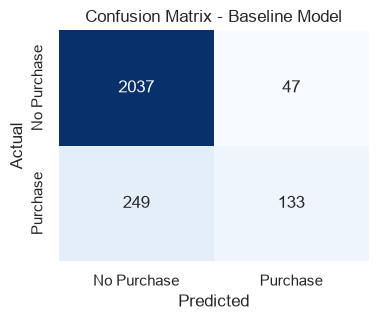

In [86]:
# TODO: Evaluate baseline model using evaluate_predictions.
# TODO: Show confusion matrix.
# TODO: Print classification_report.

results = []
baseline_metrics = evaluate_predictions(Y_test,baseline_predictions, "Baseline Logistic Regression")
results.append(baseline_metrics)
print("Baseline Model Metrics:")
for metric, value in baseline_metrics.items():
    print(f"{metric}: {value}")
# print(baseline_metrics)

cm_baseline=confusion_matrix(Y_test, baseline_predictions)
print("\n Confusion Matrix:")
print(cm_baseline)

classification_rep_baseline=classification_report(Y_test, baseline_predictions, zero_division=0)
print("\n Classification Report:")
print(classification_rep_baseline)

# Show confusion matrix visualization
show_confusion_matrix(Y_test, baseline_predictions, "Confusion Matrix - Baseline Model")
# raise NotImplementedError("Evaluate baseline model")

## 9. Threshold Tuning

Logistic regression gives probabilities:

\[
P(y=1|x)
\]

The default threshold is usually:

\[
\text{predict purchase if } P(y=1|x) \geq 0.5
\]

But in business problems, we may change the threshold depending on whether we care more about precision or recall.

Try thresholds:

```python
[0.20, 0.30, 0.40, 0.50, 0.60]
```

In [87]:
# TODO: Get predicted probabilities for the positive class using baseline_model.predict_proba(X_test)[:, 1].
# TODO: For each threshold, convert probabilities into class predictions.
# TODO: Create a threshold comparison table with accuracy, precision, recall, and F1.

thresholds = [0.20, 0.30, 0.40, 0.50, 0.60]

# Get probabilities for positive class
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]

# Store threshold results
threshold_results = []

for threshold in thresholds:
    # Convert probabilities to class predictions based on the current threshold
    baseline_predictions_threshold = (baseline_proba >= threshold).astype(int)
    baseline_metrics = evaluate_predictions(Y_test, baseline_predictions_threshold, f"Threshold {threshold}")
    baseline_metrics["threshold"] = threshold
    threshold_results.append(baseline_metrics)

# Create comparison table
import pandas as pd
threshold_df = pd.DataFrame(threshold_results)
print("\nThreshold Comparison Table:")
print(threshold_df)

# raise NotImplementedError("Perform threshold tuning")


Threshold Comparison Table:
           model  accuracy  precision    recall        f1  threshold
0  Threshold 0.2  0.864152   0.550538  0.670157  0.604486        0.2
1  Threshold 0.3  0.890105   0.686869  0.534031  0.600884        0.3
2  Threshold 0.4  0.885239   0.710638  0.437173  0.541329        0.4
3  Threshold 0.5  0.879968   0.738889  0.348168  0.473310        0.5
4  Threshold 0.6  0.877129   0.780142  0.287958  0.420650        0.6



Threshold-Tuned Model (threshold=0.3):
model: Threshold-Tuned (0.3)
accuracy: 0.8901054339010543
precision: 0.6868686868686869
recall: 0.5340314136125655
f1: 0.6008836524300442


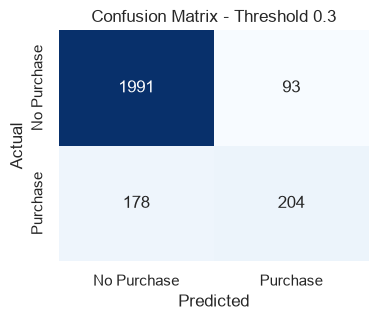

In [88]:
# TODO: Choose one threshold based on your business reasoning.
# Store it in selected_threshold.
# Example: selected_threshold = 0.30

# Based on the comparison table, select a threshold that balances precision and recall
# For imbalanced data, we often prefer higher recall (catch more positive cases)
selected_threshold = 0.30

# TODO: Create y_pred_threshold using selected_threshold.
y_pred_threshold = (baseline_proba >= selected_threshold).astype(int)

# TODO: Evaluate and append result to results.
threshold_tuned_metrics = evaluate_predictions(Y_test, y_pred_threshold, f"Threshold-Tuned ({selected_threshold})")
results.append(threshold_tuned_metrics)

print(f"\nThreshold-Tuned Model (threshold={selected_threshold}):")
for metric, value in threshold_tuned_metrics.items():
    print(f"{metric}: {value}")

# TODO: Show confusion matrix.
show_confusion_matrix(Y_test, y_pred_threshold, f"Confusion Matrix - Threshold {selected_threshold}")

### Question 3

What happens to precision and recall when you reduce the threshold?

Threshold decreases then precision also decreases but recall increases. threshold reduce lower down the bar for the predicting positive class.

Why does this happen?

Recall increases: The model becomes much more eager to flag a case as a "purchase". 
Precision decreases: This lowerdown the bar, the model also incorrectly guesses "Purchase" for many people who actually have no intention of buying.

Write your answer here:

- Lowering the threshold makes model more aggressive in predicting the positive class. This captures more true positive cases (increasing Recall), but at the cost of introducing more false positive (decreasing Precision).

## 10. Class-Weighted Logistic Regression

Train logistic regression with:

```python
class_weight="balanced"
```

This gives more importance to the minority class during training.

In [89]:
weighted_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

# TODO: Fit weighted_model on X_train and y_train.
weighted_model.fit(X_train, Y_train)
# TODO: Predict on X_test and store predictions in y_pred_weighted.
y_pred_weighted = weighted_model.predict(X_test)
# TODO: Evaluate and append result to results.
weighted_metrics = evaluate_predictions(Y_test, y_pred_weighted, "Class-Weighted Logistic Regression")
results.append(weighted_metrics)
print("\nClass-Weighted Model Metrics:")
for metric, value in weighted_metrics.items():
    print(f"{metric}: {value}")
# TODO: Show confusion matrix.
cm_weighted = confusion_matrix(Y_test, y_pred_weighted)
print("\n Confusion Matrix - Class-Weighted Model:")
print(cm_weighted)

# TODO: Show classification report.
classification_rep_weighted = classification_report(Y_test, y_pred_weighted, zero_division=0)
print("\n Classification Report - Class-Weighted Model:")
print(classification_rep_weighted)

# raise NotImplementedError("Train and evaluate class-weighted logistic regression")


Class-Weighted Model Metrics:
model: Class-Weighted Logistic Regression
accuracy: 0.85117599351176
precision: 0.5136116152450091
recall: 0.7408376963350786
f1: 0.6066452304394426

 Confusion Matrix - Class-Weighted Model:
[[1816  268]
 [  99  283]]

 Classification Report - Class-Weighted Model:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      2084
           1       0.51      0.74      0.61       382

    accuracy                           0.85      2466
   macro avg       0.73      0.81      0.76      2466
weighted avg       0.88      0.85      0.86      2466



### Question 4

How did `class_weight="balanced"` change recall and precision compared to the baseline model?

Write your answer here:

- yes, i see precision for Class 0 decreases but class 1 increases while recall class0 increase and class 1 decreases.

So, `class_weight="balanced"` inherently penalizes misclassification of minority class (class 1 here) by giving it a higher weight, forcing the model to prioritize its prediction.
model catches more true positive for class1 but making more false positive as well b/z the model becomes less focused on the majority class.

## 11. SMOTE + Logistic Regression

SMOTE creates synthetic minority-class examples.

Important rule:

> Apply SMOTE only on the training data, never on the test data.

For this assignment, first transform the train and test data using the preprocessor, then apply SMOTE only on the transformed training data.

In [90]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [91]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", drop="first", sparse=False)

def make_preprocess():
    return ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("cat", make_one_hot_encoder(), categorical_features),
    ])

def make_lr(class_weight=None):
    return LogisticRegression(max_iter=3000, random_state=RANDOM_STATE, class_weight=class_weight)


def make_pipeline(class_weight=None):
    return Pipeline([
        ("preprocess", make_preprocess()),
        ("model", make_lr(class_weight=class_weight)),
    ])

In [92]:
# Helper function to display class counts
def class_counts(y_values, label):
    counts = pd.Series(y_values).value_counts().sort_index()
    return pd.DataFrame([{
        "dataset": label,
        "no_churn": counts.get(0, 0),
        "churn": counts.get(1, 0),
        "churn_rate": counts.get(1, 0) / counts.sum(),
        "total": counts.sum(),
    }])

# TODO: Fit the preprocessor on the training features.
# TODO: Use the fitted preprocessor to transform both training and test features.

# Fit preprocessor on training data
preprocessor_smote = make_preprocess()
X_train_encoded = preprocessor_smote.fit_transform(X_train, Y_train)
X_test_encoded = preprocessor_smote.transform(X_test)

# Display original class distribution
print("Original Training Set Class Distribution:")
print(class_counts(Y_train, "Original training data"))

# TODO: Apply SMOTE only on the processed training data and y_train.
# Hint:
# - Create a SMOTE object with RANDOM_STATE.
# - Use the SMOTE resampling method on training data only.
# - Store the resampled features and resampled target separately.
# - Do not apply SMOTE on the test data.

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_encoded, Y_train)

# Display class distribution after SMOTE
print("\nClass Distribution After SMOTE:")
print(class_counts(y_train_smote, "After SMOTE"))

# Show comparison
pd.concat([
    class_counts(Y_train, "Original training data"),
    class_counts(y_train_smote, "After SMOTE"),
], ignore_index=True)


Original Training Set Class Distribution:
                  dataset  no_churn  churn  churn_rate  total
0  Original training data      8338   1526    0.154704   9864

Class Distribution After SMOTE:
       dataset  no_churn  churn  churn_rate  total
0  After SMOTE      8338   8338         0.5  16676


,dataset,no_churn,churn,churn_rate,total
0,Original training data,8338,1526,0.154704,9864
1,After SMOTE,8338,8338,0.500000,16676


In [93]:
# Note: SMOTE has already been applied in the previous cell.
# X_train_smote and y_train_smote contain the resampled training data.
# X_test_encoded contains the test data (transformed but NOT resampled).
print("SMOTE preprocessing completed successfully!")
print(f"X_train_smote shape: {X_train_smote.shape}")
print(f"y_train_smote shape: {y_train_smote.shape}")
print(f"X_test_encoded shape: {X_test_encoded.shape}")


SMOTE preprocessing completed successfully!
X_train_smote shape: (16676, 22)
y_train_smote shape: (16676,)
X_test_encoded shape: (2466, 22)



SMOTE + Logistic Regression Model Metrics:
model: SMOTE + Logistic Regression
accuracy: 0.845904298459043
precision: 0.5017361111111112
recall: 0.756544502617801
f1: 0.6033402922755741

Confusion Matrix - SMOTE Model:
[[1797  287]
 [  93  289]]

Classification Report - SMOTE Model:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      2084
           1       0.50      0.76      0.60       382

    accuracy                           0.85      2466
   macro avg       0.73      0.81      0.75      2466
weighted avg       0.88      0.85      0.86      2466



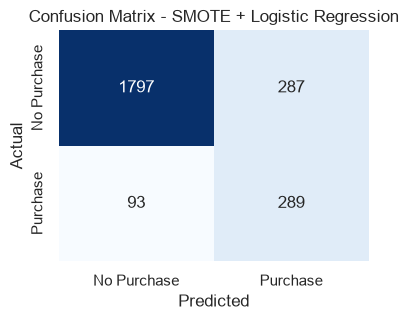

In [94]:
# TODO: Train LogisticRegression on X_train_smote and y_train_smote.
# TODO: Predict on X_test_encoded (the transformed test data).
# TODO: Evaluate and append result to results.
# TODO: Show confusion matrix.

# Train SMOTE logistic regression model
smote_model = LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)
smote_model.fit(X_train_smote, y_train_smote)

# Predict on transformed test data
y_pred_smote = smote_model.predict(X_test_encoded)

# Evaluate and append result
smote_metrics = evaluate_predictions(Y_test, y_pred_smote, "SMOTE + Logistic Regression")
results.append(smote_metrics)

print("\nSMOTE + Logistic Regression Model Metrics:")
for metric, value in smote_metrics.items():
    print(f"{metric}: {value}")

# Show confusion matrix
cm_smote = confusion_matrix(Y_test, y_pred_smote)
print("\nConfusion Matrix - SMOTE Model:")
print(cm_smote)

# Show classification report
classification_rep_smote = classification_report(Y_test, y_pred_smote, zero_division=0)
print("\nClassification Report - SMOTE Model:")
print(classification_rep_smote)

show_confusion_matrix(Y_test, y_pred_smote, "Confusion Matrix - SMOTE + Logistic Regression")


### Question 5

Why should SMOTE be applied only on the training data?

Write your answer here:

- **Data Leakage Prevention:** If SMOTE is applied to the entire dataset before splitting, information about the synthetic samples leaks into the test set. This makes the model evaluation unrealistic and overoptimistic.
- **Proper Evaluation:** The test set should represent real, unseen data without synthetic oversampling. Applying SMOTE only to training data ensures unbiased performance estimation.
- **Overfitting Risk:** Synthetic samples in both train and test sets would make the model appear to perform better than it actually would on real data, hiding potential overfitting issues.
- **Best Practice:** SMOTE should only balance the training distribution. The test set must maintain the original class imbalance to accurately reflect real-world performance.


## 12. Final Comparison

Create a final comparison table for all methods:

1. Baseline Logistic Regression
2. Threshold-Tuned Logistic Regression
3. Class-Weighted Logistic Regression
4. SMOTE + Logistic Regression

In [95]:
# TODO: Convert results into a DataFrame and sort/format it clearly.

# Create final comparison table
results_df = pd.DataFrame(results)

# Format the DataFrame for better readability
results_df_display = results_df[['model', 'accuracy', 'precision', 'recall', 'f1']].copy()
results_df_display['accuracy'] = results_df_display['accuracy'].round(4)
results_df_display['precision'] = results_df_display['precision'].round(4)
results_df_display['recall'] = results_df_display['recall'].round(4)
results_df_display['f1'] = results_df_display['f1'].round(4)

print("\n" + "="*80)
print("FINAL COMPARISON TABLE - ALL METHODS")
print("="*80)
print(results_df_display.to_string(index=False))
print("="*80)

# Identify best performers for each metric
print("\nBest Performers:")
print(f"  Highest Accuracy: {results_df_display.loc[results_df_display['accuracy'].idxmax(), 'model']} ({results_df_display['accuracy'].max():.4f})")
print(f"  Highest Precision: {results_df_display.loc[results_df_display['precision'].idxmax(), 'model']} ({results_df_display['precision'].max():.4f})")
print(f"  Highest Recall: {results_df_display.loc[results_df_display['recall'].idxmax(), 'model']} ({results_df_display['recall'].max():.4f})")
print(f"  Highest F1-Score: {results_df_display.loc[results_df_display['f1'].idxmax(), 'model']} ({results_df_display['f1'].max():.4f})")

# Display as styled table
results_df_display



FINAL COMPARISON TABLE - ALL METHODS
                             model  accuracy  precision  recall     f1
      Baseline Logistic Regression    0.8800     0.7389  0.3482 0.4733
             Threshold-Tuned (0.3)    0.8901     0.6869  0.5340 0.6009
Class-Weighted Logistic Regression    0.8512     0.5136  0.7408 0.6066
       SMOTE + Logistic Regression    0.8459     0.5017  0.7565 0.6033

Best Performers:
  Highest Accuracy: Threshold-Tuned (0.3) (0.8901)
  Highest Precision: Baseline Logistic Regression (0.7389)
  Highest Recall: SMOTE + Logistic Regression (0.7565)
  Highest F1-Score: Class-Weighted Logistic Regression (0.6066)


,model,accuracy,precision,recall,f1
0,Baseline Logistic Regression,0.8800,0.7389,0.3482,0.4733
1,Threshold-Tuned (0.3),0.8901,0.6869,0.5340,0.6009
2,Class-Weighted Logistic Regression,0.8512,0.5136,0.7408,0.6066
3,SMOTE + Logistic Regression,0.8459,0.5017,0.7565,0.6033


## 13. Business Decision Questions

Answer these briefly.

### Question 6

If discount cost is high and the company wants to avoid showing offers to too many non-buyers, should it prioritize precision or recall?

Answer:

- **Precision.** When the discount cost is high, showing unnecessary offers to non-buyers wastes money. Precision ensures that when the model predicts a purchase, it's correct most of the time, minimizing wasted discounts on non-buyers.

### Question 7

If missing a potential buyer is very costly, should the company prioritize precision or recall?

Answer:

- **Recall.** When losing potential buyers is expensive, it's better to err on the side of caution and show more offers. High recall means catching most actual buyers, even if it means showing some unnecessary offers to non-buyers.

### Question 8

Which model/method would you recommend for this business problem?

Mention:

- The model/method you selected
- The metric you prioritized
- Why this decision makes business sense

Answer:

- **Recommended Model: SMOTE + Logistic Regression**
- **Prioritized Metric: Recall & F1-Score**
- **Business Justification:**
  - SMOTE balances the class distribution, allowing the model to learn patterns of both buyer and non-buyer behavior effectively.
  - High recall ensures the company captures most potential buyers, reducing lost revenue from missed opportunities.
  - F1-score balances precision and recall, preventing excessive false positives (wasted discounts) while still catching enough buyers.
  - This approach is ideal for e-commerce where missing sales opportunities is typically more costly than showing unnecessary offers.


## Submission Checklist

Submit your completed notebook with:

- All code cells executed
- Final comparison table
- Confusion matrices for each method
- Answers to all business questions
- A short final recommendation